# Examining Surface Elevation Change Rates of the Polar Ice Sheets
 
By Natalia Havelund Andersen, DTU Space, naand@space.dtu.dk


## About

This tutorial demonstrates how to analyse and visualise surface elevation change rates over the Greenland and Antarctic ice sheets using data from the Copernicus Climate Change Service (C3S).

Surface elevation change rate (dh/dt) describes how the height of the ice sheet surface evolves over time. These changes reflect a combination of processes, including surface mass balance (e.g. snowfall and melt) and ice dynamics (e.g. glacier flow acceleration). As such, they are a key indicator for understanding ice sheet mass balance and contributions to global sea level rise.

The dataset used in this tutorial is derived from satellite radar altimetry observations acquired by multiple missions, including:
- ERS-1 and ERS-2  
- Envisat  
- CryoSat-2  
- Sentinel-3  

These missions are combined into a consistent long-term record spanning from 1992 to present. The data are processed using established methods developed within the ESA Climate Change Initiative (CCI) and further extended within C3S.

The data are accessed via the Climate Data Store (CDS). A full description of the dataset, including processing methodology and uncertainties, is available here:  
https://cds.climate.copernicus.eu/datasets/satellite-ice-sheet-elevation-change

The dataset is provided in NetCDF format and includes:
- spatial coordinates (latitude, longitude or x/y grid)  
- time dimension (monthly records)  
- surface elevation change rate (dh/dt or SEC)  
- associated uncertainty estimates  


## Objectives

In this tutorial, you will learn how to:

- Access and download ice sheet elevation change data from the CDS  
- Work with NetCDF data in Python  
- Select a time period of interest  
- Compute average surface elevation change rates over that period  
- Visualise spatial patterns of elevation change on a polar map  
- Interpret regions of ice sheet thinning and thickening  


The tutorial is designed to be easy to follow and provides step-by-step guidance from data access to visualisation.


## Prepare your environment

To download data from the CDS, you must complete three steps;
1. Register for free with the CDS at https://cds.climate.copernicus.eu/#!/home
2. Set up the CDS Application Program Interface (API), as described at https://cds.climate.copernicus.eu/api-how-to
3. Agree to the dataset terms of use - if you have not already done so you will be directed to the correct webpage the first time you try to download data. Accept the terms and conditions, and re-run the downloading code.

## Import libraries

The data is stored in netCDF4 files. To work with them, several libraries are needed. These are used to retrieve the data, unpack it, run calculations and plot the results.

### Required Python Libraries

- **cdsapi** – for downloading data from the Copernicus Climate Data Store (CDS)  
- **numpy** – for numerical calculations  
- **xarray** – for working with NetCDF datasets  
- **matplotlib** – for plotting figures  
- **cartopy** – for map projections and geospatial plotting  

### Standard Library Modules (included with Python)

- **os** – for file and directory handling  
- **glob** – for finding files using patterns  
- **shutil** – for unpacking and managing downloaded files

In [5]:
# CDS API
import cdsapi

# File handling
import shutil
import glob
import os

# Calculations
import numpy as np
import xarray as xr

# Mapping
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Plotting
import matplotlib.pyplot as plt

## Download data

Select the ice sheet of interest and retrieve the dataset. An example of how to retrieve the data is given on the CDS, under 'Show API request' on the dataset's webpage at https://cds.climate.copernicus.eu/cdsapp#!/dataset/satellite-ice-sheet-elevation-change?tab=form

The dataset comes in a zip file, and may include several files. Only the most recent is necessary - this contains all of the data in previous files, plus the latest update.  

In [36]:
# Set ice_sheet to the desired ice sheet, either 'antarctica' or 'greenland'
# This will be used to select data, and later to set up plot defaults

ice_sheet = 'greenland'

try:
    
    # Download data from the CDS

    c = cdsapi.Client()

    c.retrieve(
    'satellite-ice-sheet-elevation-change',
    {
        'variable': 'all',
        'format': 'zip',
        'domain': 'greenland',
        'climate_data_record_type': 'icdr',
        'version': '6_0',
    },
    'download.zip')

    # Unpack the zip file and remove the zipped data

    shutil.unpack_archive('download.zip', '.')
    os.remove('download.zip')
except:
    pass

# List the files contained and select the latest netCDF (.nc) file. Print its filename

list_of_files = glob.glob('*.nc') # * means all if need specific format then *.nc
latest_file = max(list_of_files, key=os.path.getctime)
print('In the following you are seeing the data from: \n'+latest_file)

2026-05-01 13:39:43,113 INFO Request ID is c3c28ff3-3e6e-4dbb-a09a-1dc623713492
2026-05-01 13:39:43,191 INFO status has been updated to accepted
2026-05-01 13:39:56,787 INFO status has been updated to running
2026-05-01 13:40:04,516 INFO status has been updated to successful


497078a7f2e1b1cd5689d5863e8fe38f.zip:   0%|          | 0.00/19.4M [00:00<?, ?B/s]

In the following you are seeing the data from: 
C3S_GrIS_RA_SEC_25km_Vers6_199108-202601_2026-04-18.nc


## Examine the data

Open the data file and list its contents. These include descriptive comments.

In [37]:
# Open the NetCDF file

ds = xr.open_dataset(latest_file)

# Print contents list

print('The data file contains the following:')
print(ds)

The data file contains the following:
<xarray.Dataset>
Dimensions:          (x: 65, y: 123, t: 406)
Coordinates:
  * x                (x) float32 -7.393e+05 -7.143e+05 ... 8.357e+05 8.607e+05
  * y                (y) float32 -3.478e+06 -3.453e+06 ... -4.531e+05 -4.281e+05
Dimensions without coordinates: t
Data variables: (12/16)
    time             (t) datetime64[ns] ...
    start_time       (t) datetime64[ns] ...
    end_time         (t) datetime64[ns] ...
    grid_projection  |S1 ...
    lat              (y, x) float32 ...
    lon              (y, x) float32 ...
    ...               ...
    dhdt_stabil      (y, x, t) float32 ...
    dhdt_ok          (y, x, t) int8 ...
    dist             (y, x, t) float32 ...
    land_mask        (y, x) int8 ...
    high_slope       (y, x) int8 ...
    area             (y, x) float32 ...
Attributes: (12/32)
    Title:                Surface Elevation change of the Greenland ice sheet...
    institution:          Copernicus Climate Change Service, 

This NetCDF file contains data related to surface elevation change of the ice sheet. Here's a breakdown of the file structure and its contents:

**Dimensions:** 
- `x`: Projected longitudinal coordinates with values ranging from approximately -739,300 to 860,700 (for Greenland).
- `y`: Projected latitudinal coordinates with values ranging from approximately -3,478,000 to -428,100 (for Greenland).
- `t`: Time coordinates.

**Data Variables:** 
- Among others, the elevation change is represented in the variable `dhdt`.

Additional meta-data is included in the file's attributes.


## Calculate averages and plot

The ice sheets are split into 25km by 25km cells. In each cell is a series of surface elevation change rates (called 'sec' for Antarctica or 'dhdt' for Greenland), at times given by the 'time' array. Take the average of the rates for your chosen time period. Plot using a mapping library.

### Why is data missing from the South Pole? 

The change rates series may not have a value at every time - a blank (represented by not-a-number or 'NaN') is left where measurements could not be made or were of low quality. A special case is the interior of the Antarctic ice sheet, below 81.5&deg;S. Five of the six satellites used to make the dataset could not see into this region. All the data there came from CryoSat-2, which has a more tilted orbit. Even CryoSat-2 can only see down to 88&deg;S and so there is a circular region around the South Pole which never contains data. 

This has a further consequence. In the simple averaging calculation below, data from the region seen only by CryoSat-2 will only be available for the CryoSat-2 mission period, which began in 2010, even if the start of the averaging period is before that.

### What would be a good colour palette for the plot?

Many published plots, such as the one on this page https://www.cnet.com/science/climate/nasa-study-reveals-decades-of-antarctic-ice-loss-that-went-under-the-radar/plots, use a red-to-blue colour scale, where red represents ice loss, blue represents gain and the white centre represents no change. This works well if the data range is centred on zero, but looks misleading when it is not. The scale used in the example code, a red-to-green-to-blue scale, is a colourblind accessible alternative.

If the data range is not centred on zero, then the python 'viridis' colour scale, which is also colourblind accessible, is an example of a better choice.

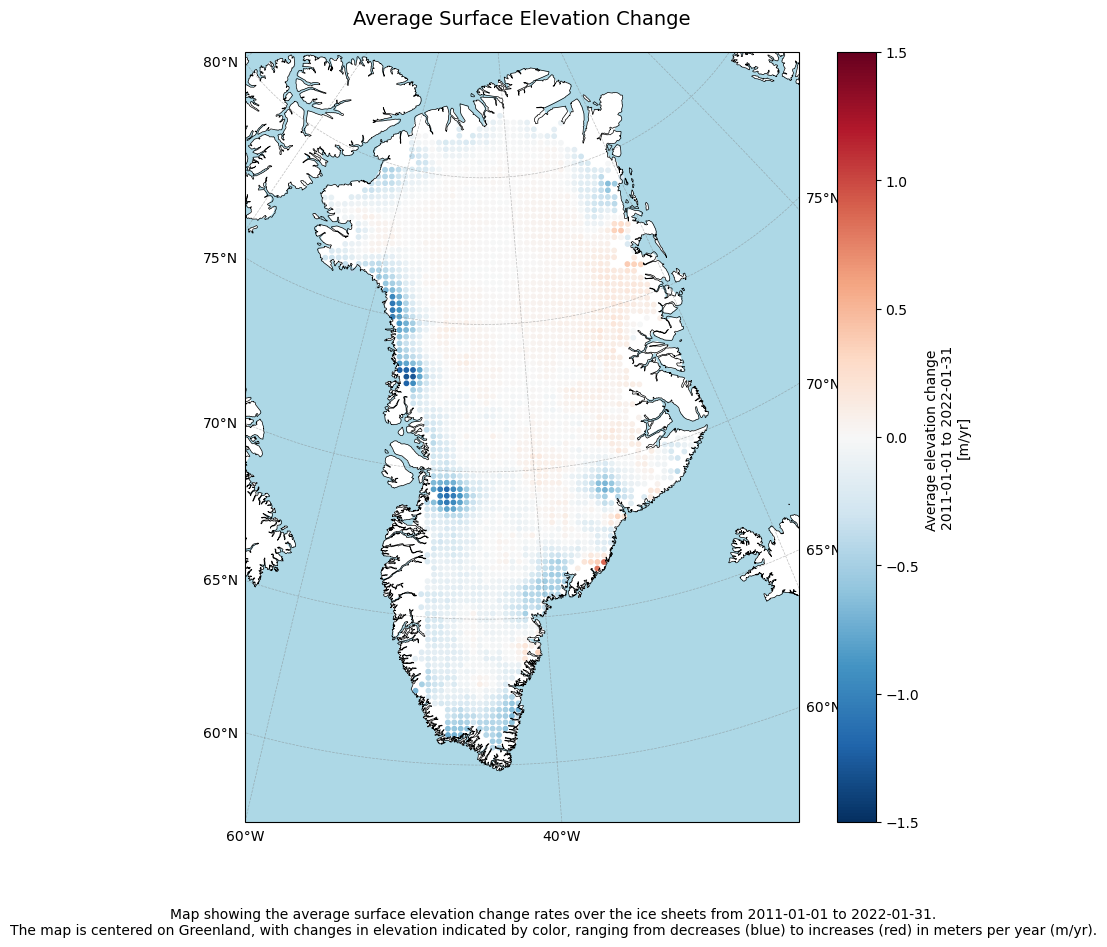

In [38]:
#plot the average elevation change from "Start time" to "End time"
Start_time = np.datetime64('2011-01-01 00:00:00')
End_time   = np.datetime64('2022-01-31 00:00:00')
Tbool = (ds['time']>= Start_time) & (ds['time']< End_time)

# Available time range in dataset
tmin = ds["time"].values.min()
tmax = ds["time"].values.max()

if Start_time < tmin:
    print(
        f"WARNING: Start_time {str(Start_time)[:10]} is before the first available data "
        f"({str(tmin)[:10]}). Using {str(tmin)[:10]} instead."
    )
    Start_time = tmin

if End_time > tmax:
    print(
        f"WARNING: End_time {str(End_time)[:10]} is after the last available data "
        f"({str(tmax)[:10]}). Using {str(tmax)[:10]} instead."
    )
    End_time = tmax

Tbool = (ds["time"] >= Start_time) & (ds["time"] < End_time)

if Tbool.sum() == 0:
    raise ValueError(
        f"No data available between {str(Start_time)[:10]} and {str(End_time)[:10]}. "
        f"Available data range is {str(tmin)[:10]} to {str(tmax)[:10]}."
    )

# Create a figure and axis with a specific projection (e.g., Orthographic projection centered on Greenland)
fig = plt.figure(figsize=(10, 10))

if 'green' in ice_sheet:
    lon = ds['lon']
    lat = ds['lat']
    dhdt_ave = np.mean(ds['dhdt'][:,:,Tbool], axis=2)
    ext= [-60, -25, 57, 84]

    ax = plt.axes(projection=ccrs.Orthographic(-45, 71))


else:
    lon = ds['longitude']
    lat = ds['latitude']
    dhdt_ave = np.mean(ds['sec'][:,:,Tbool], axis=2)
    ext = [-180, 180, -90, -60]
    
    ax = plt.axes(
            projection=ccrs.SouthPolarStereo(
                central_longitude=0
            )
        )
    
# Add the coastlines  to the map    
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)

# Set the extent of the map to the longitude and latitude range 
ax.set_extent(ext, crs=ccrs.PlateCarree())

# Add land and ocean features
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Add latitude and longitude gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Remove latitude labels at the top
gl.top_labels = False

# Set the label spacing to display labels only once on either side
gl.xlabels_top = False
gl.xlabels_bottom = True
gl.ylabels_left = True
gl.ylabels_right = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

 
# Plot data
sc = ax.scatter(lon, lat, 10,dhdt_ave,cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin =-1.5,vmax = 1.5)

# Add colorbar to map
cbar = plt.colorbar(sc,label='Data')

# Add units to colorbar
cbar.set_label('Average elevation change \n'+str(Start_time)[:10]+ ' to ' +str(End_time)[:10]+ '\n[m/yr]')

# Add title and caption to the plot
title = "Average Surface Elevation Change"
ax.set_title(title, fontsize=14, pad=20)
fig.text(0.5, 0.01, 
         f"Map showing the average surface elevation change rates over the ice sheets from {str(Start_time)[:10]} to {str(End_time)[:10]}.\n"
         f"The map is centered on {'Greenland' if 'green' in ice_sheet else 'Antarctica'}, with changes in elevation indicated by color, ranging from decreases (blue) to increases (red) in meters per year (m/yr).",
         ha='center', va='center', fontsize=10, color='black')



# Show the map
plt.show()

### Cumulative Elevation Change at Selected Locations

Surface elevation change rates are integrated over time to estimate cumulative elevation change at selected locations. This provides a more intuitive view of whether a region has experienced net surface lowering or thickening during the study period.

Sermeq Kujalleq: selected grid cell lat=69.15, lon=-48.50
Summit: selected grid cell lat=72.68, lon=-38.60
79N Glacier: selected grid cell lat=79.30, lon=-23.00


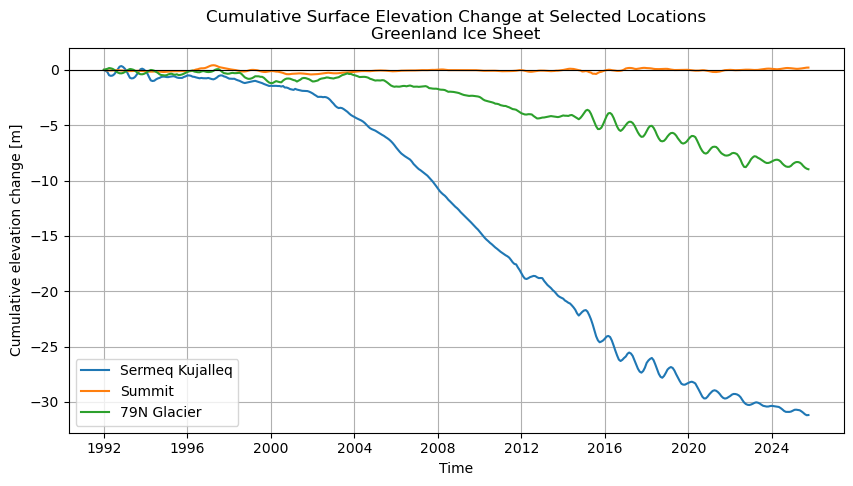

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Select points and variables based on ice sheet
# -----------------------------------------------------
if "green" in ice_sheet.lower():

    points = [
        {"name": "Sermeq Kujalleq", "lon": -48.6,  "lat": 69.19},
        {"name": "Summit",          "lon": -38.45, "lat": 72.57},
        {"name": "79N Glacier",     "lon": -23.2,  "lat": 79.3},
    ]

    lon_grid = ds["lon"].values
    lat_grid = ds["lat"].values
    sec = ds["dhdt"].values        # usually (y, x, time) or (x, y, time)
    time = ds["time"].values
    title_sheet = "Greenland Ice Sheet"

else:

    points = [
        {"name": "Pine Island", "lon": -100.0, "lat": -75.1},
        {"name": "Thwaites",    "lon": -106.5, "lat": -75.5},
        {"name": "Interior",    "lon": 0.0,    "lat": -82.0},
    ]

    lon_grid = ds["longitude"].values
    lat_grid = ds["latitude"].values
    sec = ds["sec"].values         # (y, x, t)
    time = ds["time"].values
    title_sheet = "Antarctic Ice Sheet"

# -----------------------------------------------------
# Ensure sec has shape (y, x, time)
# -----------------------------------------------------
if sec.shape[0:2] != lon_grid.shape:
    if sec.shape[1::-1] == lon_grid.shape:
        sec = np.transpose(sec, (1, 0, 2))
    else:
        raise ValueError(
            f"SEC spatial shape {sec.shape[0:2]} does not match lon/lat shape {lon_grid.shape}"
        )

# -----------------------------------------------------
# Time step in years
# -----------------------------------------------------
dt_years = np.diff(time) / np.timedelta64(1, "D") / 365.25

# -----------------------------------------------------
# Valid cells: require at least 20 valid time steps
# -----------------------------------------------------
valid_cells = np.isfinite(sec).sum(axis=2) > 20

# -----------------------------------------------------
# Plot cumulative elevation change
# -----------------------------------------------------
plt.figure(figsize=(10, 5))

for p in points:

    # Convert longitude convention if needed
    if np.nanmax(lon_grid) > 180:
        p_lon = p["lon"] % 360
    else:
        p_lon = p["lon"]

    dlon = np.abs(lon_grid - p_lon)
    dlon = np.minimum(dlon, 360 - dlon)

    dist = dlon**2 + (lat_grid - p["lat"])**2

    # Use nearest valid cell
    dist_valid = np.where(valid_cells, dist, np.inf)

    if not np.isfinite(dist_valid).any():
        print(f"No valid data found for {p['name']}")
        continue

    iy, ix = np.unravel_index(np.nanargmin(dist_valid), dist.shape)

    ts = sec[iy, ix, :].astype(float)

    if np.all(~np.isfinite(ts)):
        print(f"{p['name']} skipped: selected grid cell has no valid data")
        continue

    # Fill small gaps before cumulative sum
    finite = np.isfinite(ts)

    if finite.sum() < 2:
        print(f"{p['name']} skipped: too few valid observations")
        continue

    ts_filled = np.interp(
        np.arange(len(ts)),
        np.where(finite)[0],
        ts[finite]
    )

    cumulative = np.zeros_like(ts_filled, dtype=float)
    cumulative[1:] = np.cumsum(ts_filled[:-1] * dt_years)

    print(
        f"{p['name']}: selected grid cell "
        f"lat={lat_grid[iy, ix]:.2f}, lon={lon_grid[iy, ix]:.2f}"
    )

    plt.plot(time, cumulative, label=p["name"])

plt.axhline(0, color="k", linewidth=0.8)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Cumulative elevation change [m]")
plt.title(f"Cumulative Surface Elevation Change at Selected Locations\n{title_sheet}")
plt.grid(True)
plt.show()

## Key Take Home Points

- **Surface Elevation Change Data**: The dataset provides spatial and temporal information on ice sheet surface elevation change rates (dh/dt), derived from multi-mission satellite radar altimetry. These data are essential for understanding ice sheet behaviour and their role in global sea level change.

- **Spatial and Temporal Analysis**: The notebook combines spatial mapping with time series analysis at selected locations, allowing both large-scale patterns and regional variability in elevation change to be explored.

- **Time Range Selection**: Users can define a custom time period to investigate changes over specific intervals. This enables analysis of trends, variability, and potential shifts in ice sheet behaviour over time.

- **Regional Differences**: Coastal and outlet glacier regions typically exhibit larger and more variable elevation changes, while interior regions tend to show smaller and more stable signals. These differences reflect variations in ice dynamics and surface mass balance.

- **Data Source and Methods**: The dataset is produced within the Copernicus Climate Change Service (C3S) using observations from multiple satellite altimetry missions (ERS-1/2, Envisat, CryoSat-2, Sentinel-3), combined into a consistent long-term record.

- **Visualization and Interpretation**: The map visualization highlights spatial patterns of elevation change, while the time series provide insight into temporal evolution. Together, these approaches support a more comprehensive understanding of ice sheet change.

- **Limitations**: The analysis is based on gridded elevation change rates and does not directly account for density variations or ice dynamics in detail. Interpretation should therefore consider the simplified nature of the dataset.

